In [8]:
import librosa
import os
import soundfile as sf
sr = 44100
music_path = "C:/Users/oboyle/Desktop/TFM/datasets/OneLastTime.wav"
music, _ = librosa.load(music_path, sr=sr, mono=True)
print(len(music))
timeStart = int((2*60+36)*sr)
clipLength = int(5*sr)
music_trimmed = music[timeStart:timeStart+clipLength+1]
print(len(music_trimmed))

trimmedName = f"{music_path}_trimmed.wav"
trimmedPath = os.path.join("C:/Users/oboyle/Desktop/TFM/datasets", trimmedName)
sf.write(trimmedPath, music_trimmed, sr) 

12744548
220501


Original lengths -> Raw: 220501, WM: 220160
Calculated offset: 0 samples
Aligned lengths  -> Raw: 220160, WM: 220160


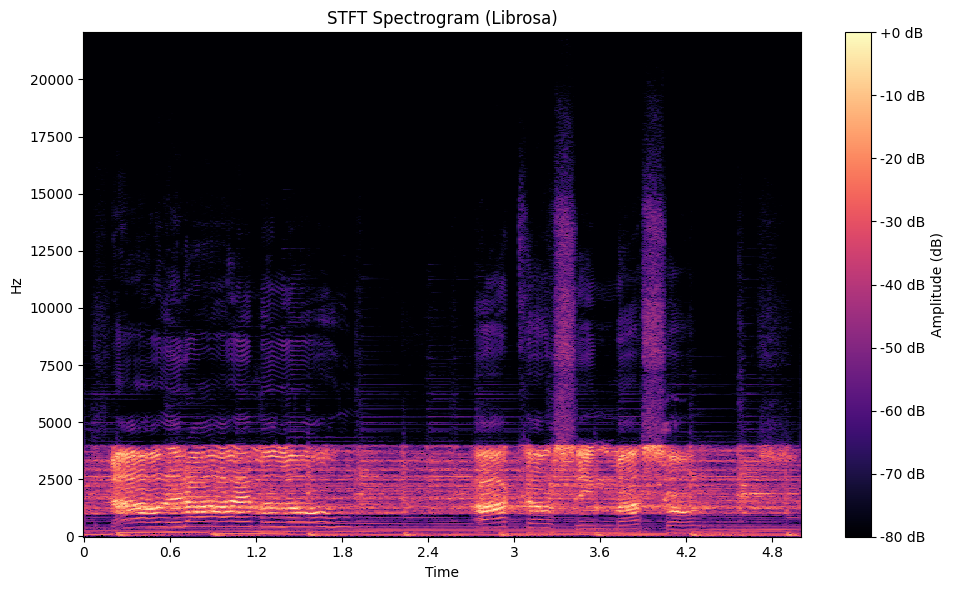

In [16]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from scipy import signal

def align_audio_arrays(raw_audio, wm_audio):
    """
    Automatically aligns two audio arrays using cross-correlation 
    and crops them to exactly the same length.
    """
    print(f"Original lengths -> Raw: {len(raw_audio)}, WM: {len(wm_audio)}")
    
    # 1. Calculate the cross-correlation (using method='fft' for speed)
    corr = signal.correlate(raw_audio, wm_audio, mode='full', method='fft')
    
    # 2. Find the lag (offset) that has the highest correlation peak
    lags = signal.correlation_lags(len(raw_audio), len(wm_audio), mode='full')
    optimal_lag = lags[np.argmax(corr)]
    
    print(f"Calculated offset: {optimal_lag} samples")
    
    # 3. Align the starts based on the lag
    if optimal_lag > 0:
        # The raw audio starts before the WM audio (WM missing start samples)
        aligned_raw = raw_audio[optimal_lag:]
        aligned_wm = wm_audio
    elif optimal_lag < 0:
        # The WM audio starts before the raw audio (Raw missing start samples)
        aligned_raw = raw_audio
        aligned_wm = wm_audio[-optimal_lag:]
    else:
        # They start at the exact same time
        aligned_raw = raw_audio
        aligned_wm = wm_audio
        
    # 4. Crop the tails so they are exactly the same length
    min_len = min(len(aligned_raw), len(aligned_wm))
    aligned_raw = aligned_raw[:min_len]
    aligned_wm = aligned_wm[:min_len]
    
    print(f"Aligned lengths  -> Raw: {len(aligned_raw)}, WM: {len(aligned_wm)}")
    
    return aligned_raw, aligned_wm

# --- How to use it ---
# raw_aligned, wm_aligned = align_audio_arrays(raw_array, wm_array)

# Now you can confidently calculate your STFTs on the aligned arrays!

rawAudio = "audio_processed/OneLastTime_trimmed.wav"
wmAudio = "audio_processed/OneLastTime_trimmed_watermarked-r1c1.wav"
sr = 44100

rawSignal,_ =  librosa.load(rawAudio, sr=sr, mono=True)
wmSignal,_ = librosa.load(wmAudio, sr=sr, mono=True)
rawSignal,wmSignal = align_audio_arrays(rawSignal, wmSignal)
# 1. Generate the STFT
rawD = librosa.stft(rawSignal, n_fft=2048, hop_length=512)
wmD = librosa.stft(wmSignal, n_fft=2048, hop_length=512)
wmSTFT = wmD-rawD
# 2. Convert the amplitude (magnitude) to Decibels (dB)
# The ref=np.max argument scales the values relative to the loudest sound
wmSTFT_dB = librosa.amplitude_to_db(np.abs(wmSTFT), ref=np.max)

# 3. Plot the Spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(
    wmSTFT_dB, 
    sr=sr,       # Pass your audio's sample rate
    hop_length=512,       # Must match what you used in librosa.stft
    x_axis='time',        # Formats the X-axis as HH:MM:SS
    y_axis='linear',      # Use 'linear' or 'log' for frequency scaling
    cmap='magma'          # 'magma' or 'viridis' are great color maps for audio
)

plt.colorbar(format='%+2.0f dB', label='Amplitude (dB)')
plt.title('STFT Spectrogram (Librosa)')
plt.tight_layout()
plt.show()